# Importing Libraries

In [1]:
#Ignore warnings
import warnings
warnings.filterwarnings("ignore")

from __future__ import print_function

import matplotlib.pyplot as plt
import missingno as msno

import numpy as np
import pandas as pd

import random as rd

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import minmax_scale
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import QuantileTransformer

import seaborn as sns
sns.set(style="white", color_codes=True)

%matplotlib inline


import warnings
warnings.simplefilter('ignore')

# Helping Functions

In [2]:
def systematic_sample(df, size):
    length = len(df)
    interval = length // size
    rd.seed(None)
    first = rd.randint(0, interval)
    indexes = np.arange(first, length, step = interval)
    return df.iloc[indexes]

In [3]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [4]:
def fill_na(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtypes in ["float", "int"]:
                df[col].fillna(df[col].mean(), inplace=True)        
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)

# Data Loading

In [5]:
df = pd.read_csv("/kaggle/input/titanic/train.csv", usecols = ["Age", "Fare"])

# Data Inspection

In [6]:
systematic_sample(df, 5)

,Age,Fare
165,9.0,20.5250
343,25.0,13.0000
521,22.0,7.8958
699,42.0,7.6500
877,19.0,7.8958


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     714 non-null    float64
 1   Fare    891 non-null    float64
dtypes: float64(2)
memory usage: 14.0 KB


In [8]:
df.describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [9]:
df.skew()

Age     0.389108
Fare    4.787317
dtype: float64

In [10]:
df.kurtosis()

Age      0.178274
Fare    33.398141
dtype: float64

# Missing Values

In [11]:
missing_values_table(df)

Your selected dataframe has 2 columns.
There are 1 columns that have missing values.


,Missing Values,% of Total Values
Age,177,19.9


<Axes: >

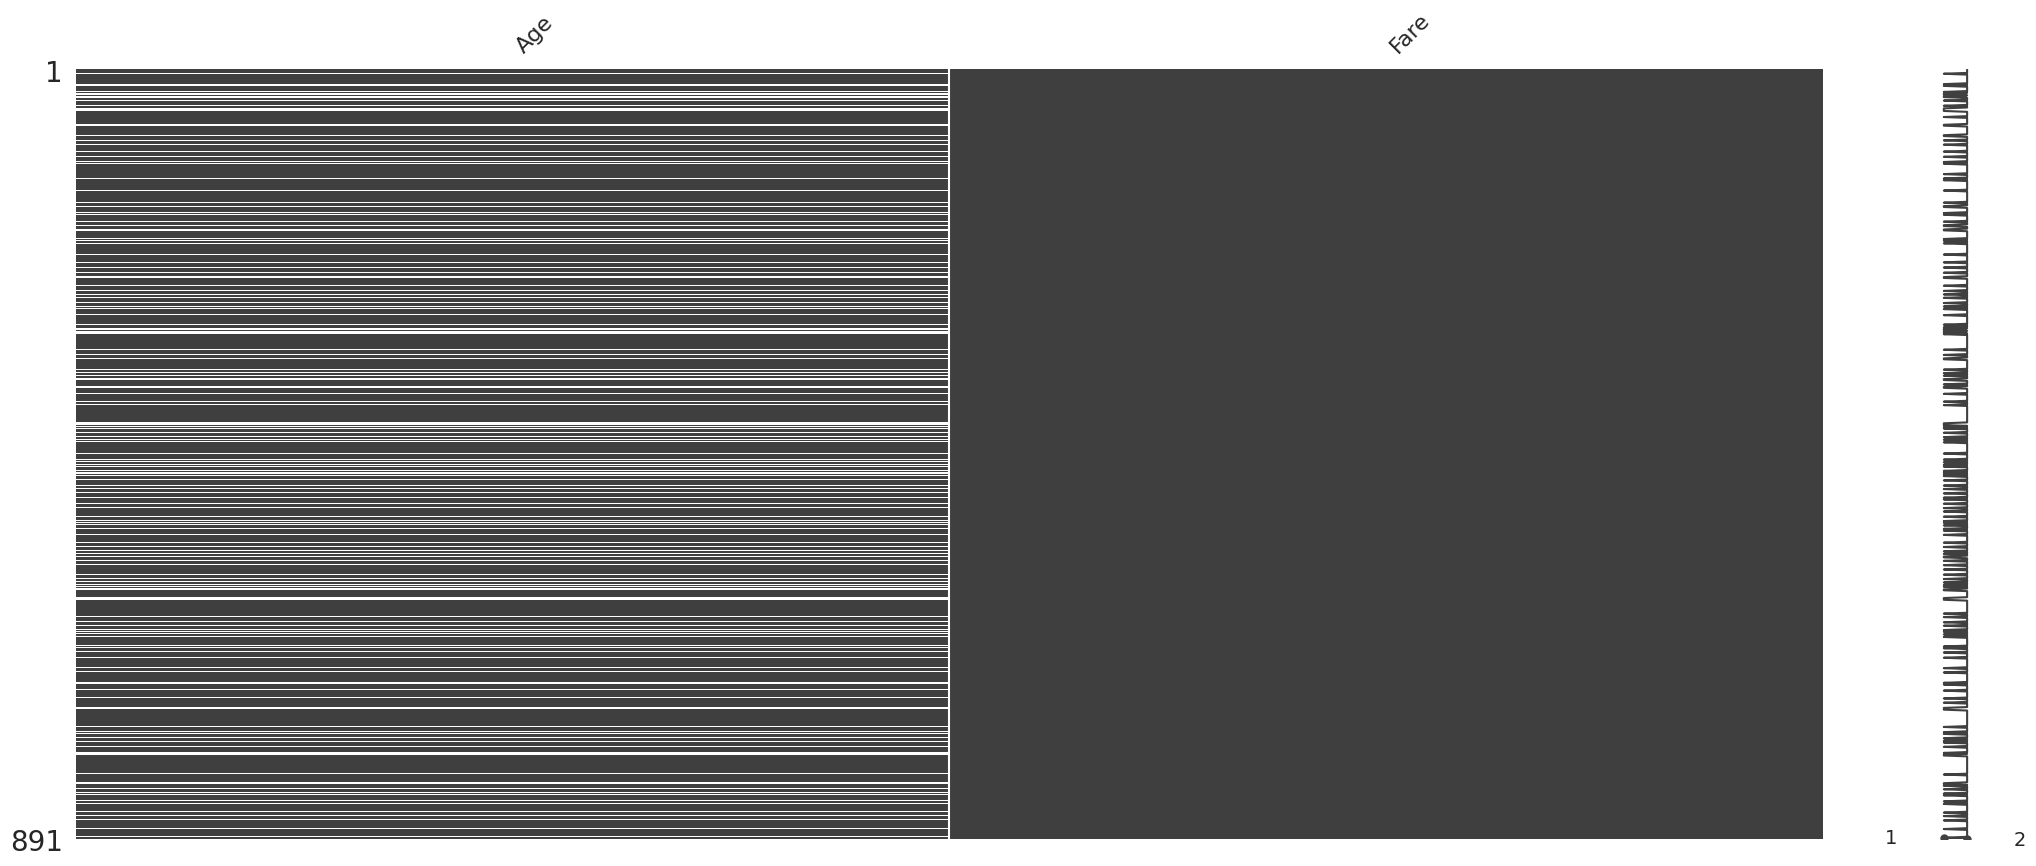

In [12]:
msno.matrix(df)

In [13]:
fill_na(df)

<Axes: >

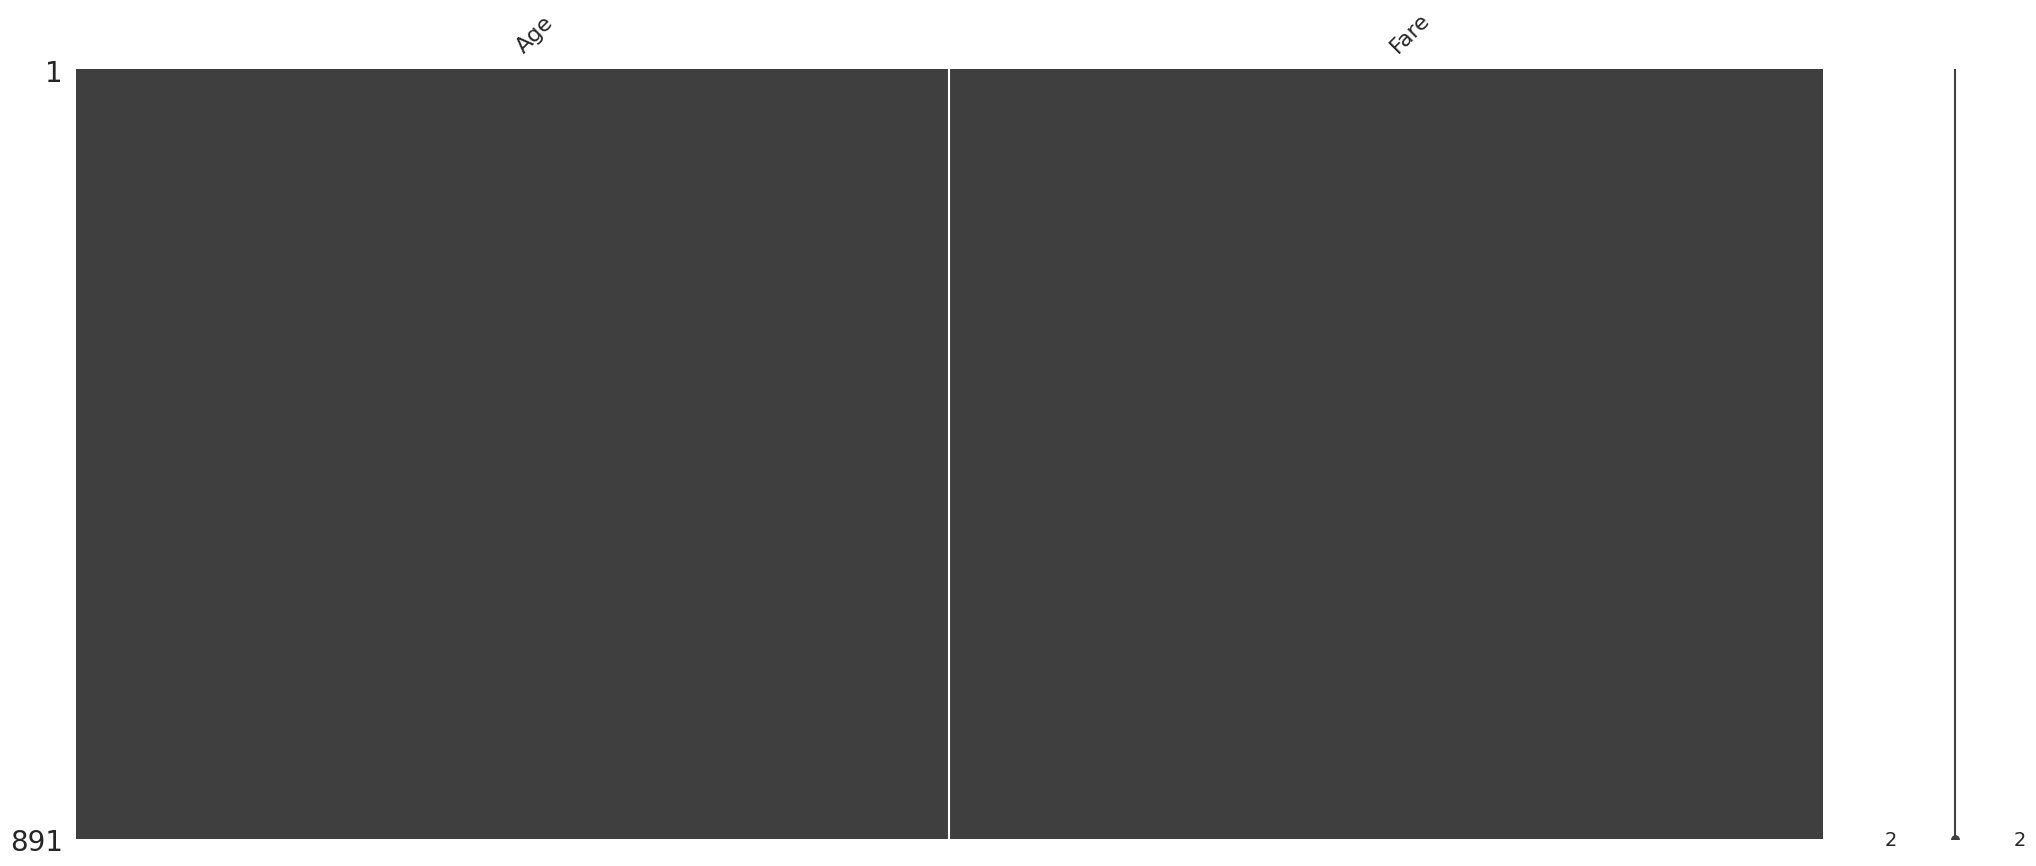

In [14]:
msno.matrix(df)

# Age

<Axes: ylabel='Frequency'>

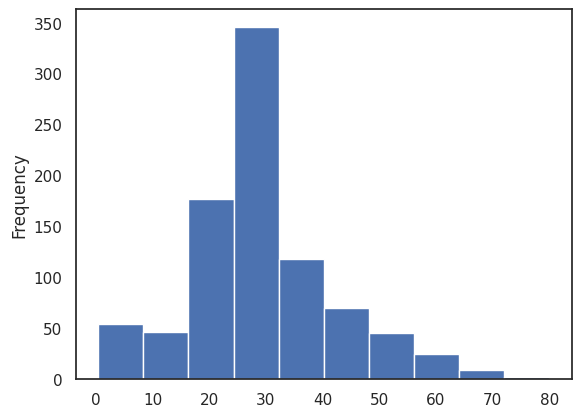

In [15]:
df["Age"].plot(kind = "hist")

In [16]:
dfX = pd.DataFrame(df['Age'])
col = dfX['Age'].values.reshape(-1, 1)

scalers = [
    #('Unscaled data', X),
    ('standard scaling', StandardScaler()),
    ('min-max scaling', MinMaxScaler()),
    ('max-abs scaling', MaxAbsScaler()),
    ('robust scaling', RobustScaler(quantile_range=(25, 75))),
    ('quantile transformation (uniform pdf)', QuantileTransformer(output_distribution='uniform')),
    ('quantile transformation (gaussian pdf)', QuantileTransformer(output_distribution='normal')),
    ('sample-wise L2 normalizing', Normalizer())
]

for scaler in scalers:
    dfX[scaler[0]] = scaler[1].fit_transform(col)

In [17]:
systematic_sample(dfX, 5)

,Age,standard scaling,min-max scaling,max-abs scaling,robust scaling,quantile transformation (uniform pdf),quantile transformation (gaussian pdf),sample-wise L2 normalizing
129,45.000000,1.177469,0.560191,0.562500,1.176991,0.878090,1.165491,1.0
307,17.000000,-0.977252,0.208344,0.212500,-0.976855,0.119101,-1.179492,1.0
485,29.699118,0.000000,0.367921,0.371239,0.000000,0.529775,0.074705,1.0
663,36.000000,0.484880,0.447097,0.450000,0.484683,0.769101,0.735890,1.0
841,16.000000,-1.054207,0.195778,0.200000,-1.053778,0.102247,-1.268851,1.0


In [18]:
orig = dfX['Age']
orig_mean = orig.mean()
bins = 50
alpha=0.5

def plot_experiment(name):
    normalized = dfX[name]
    plt.figure(figsize=(10,5))
    plt.hist(orig, bins, alpha=alpha, label='Original')
    plt.axvline(orig_mean, color='k', linestyle='dashed', linewidth=1)

    plt.hist(normalized, bins, alpha=alpha, label=name)
    plt.axvline(normalized.mean(), color='k', linestyle='dashed', linewidth=1)
    plt.legend(loc='upper right')

    plt.figure(figsize=(5,5))
    g = sns.jointplot(x="Age", y=name, data=dfX, kind='hex', ratio=3)
    #sns.violinplot(x='median_income', data=dfX, )
    #sns.violinplot(x='standard scaling', data=dfX)
    #plt.boxplot(dfX['median_income'])
    #plt.boxplot(dfX['standard scaling'])
    plt.show()

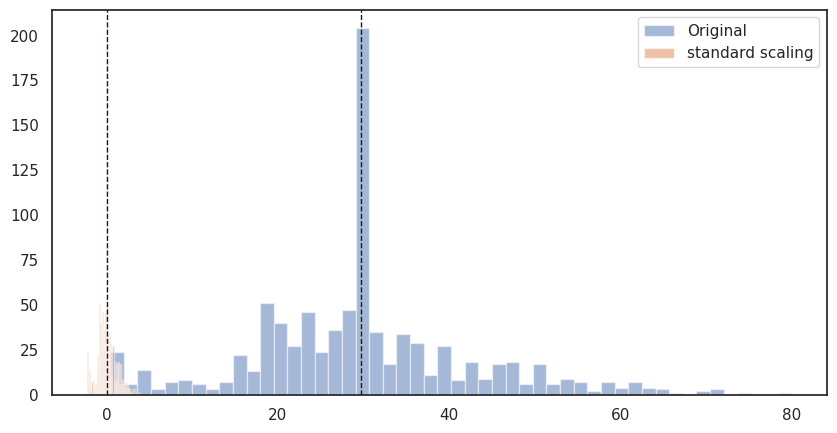

<Figure size 500x500 with 0 Axes>

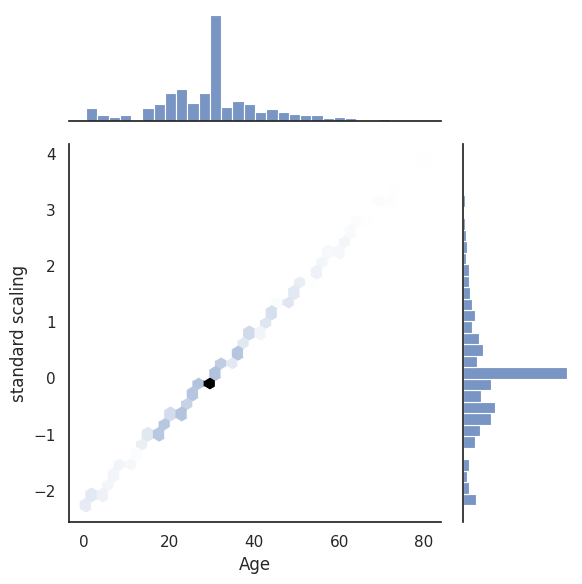

In [19]:
plot_experiment('standard scaling')

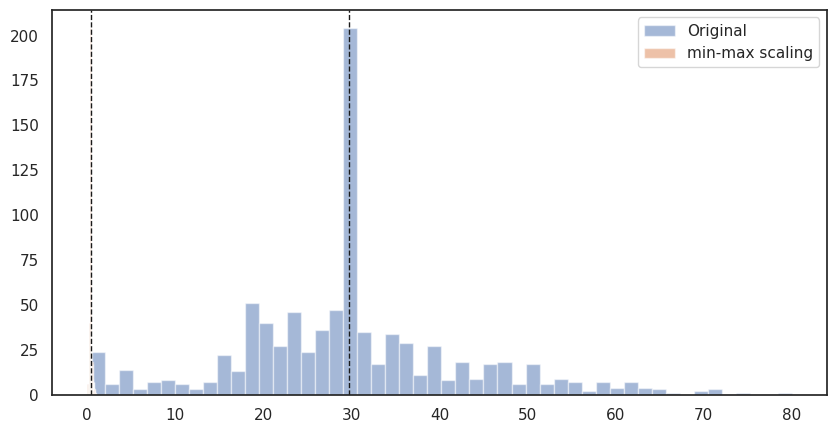

<Figure size 500x500 with 0 Axes>

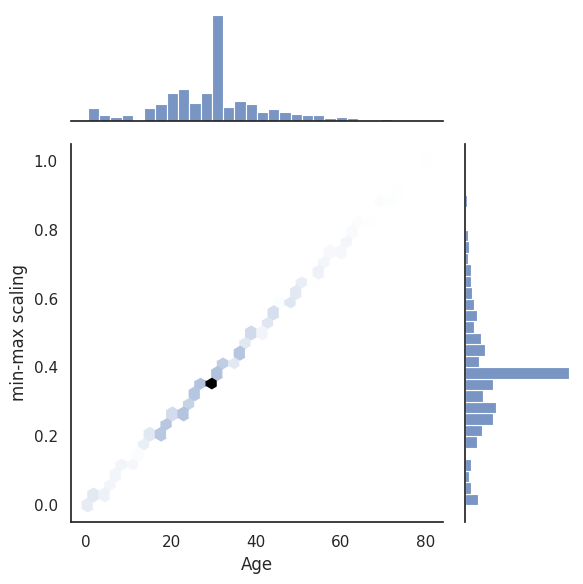

In [20]:
plot_experiment('min-max scaling')

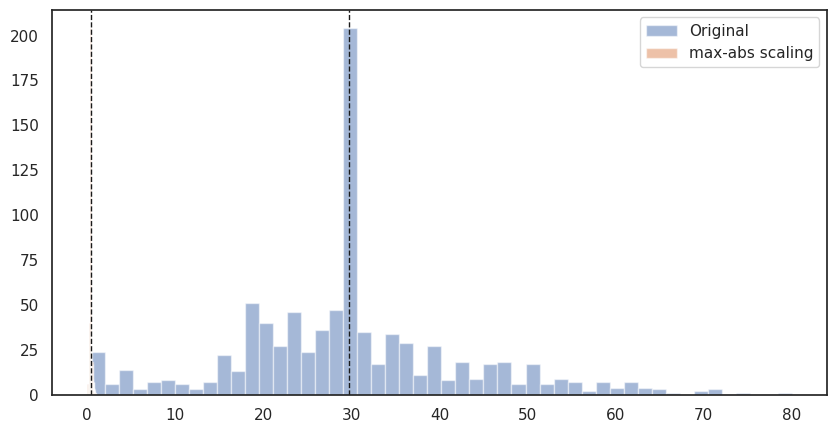

<Figure size 500x500 with 0 Axes>

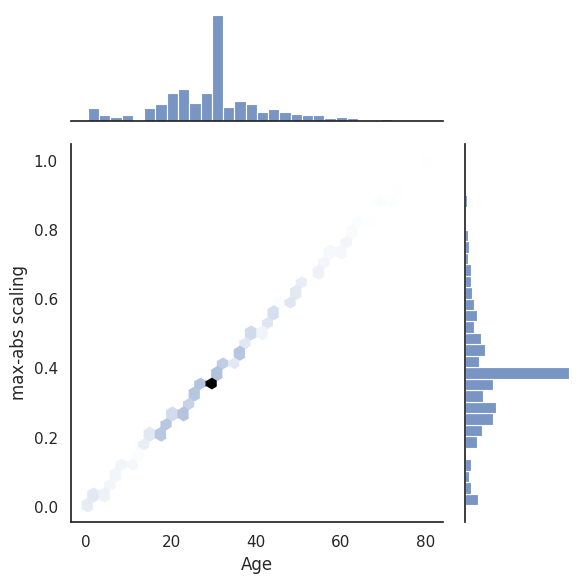

In [21]:
plot_experiment('max-abs scaling')

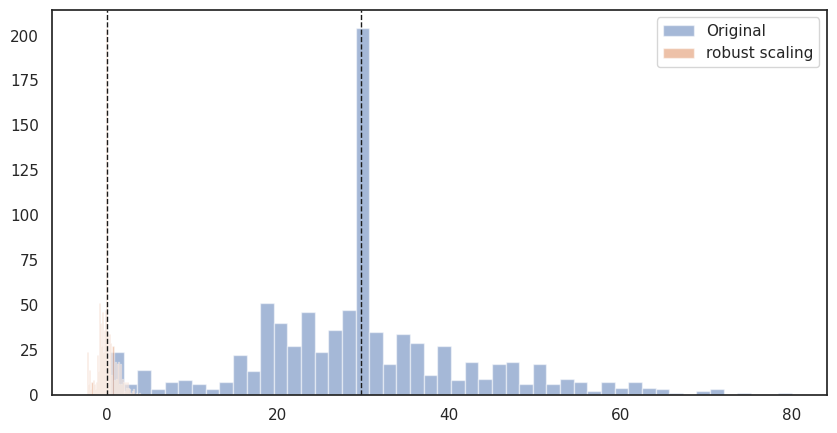

<Figure size 500x500 with 0 Axes>

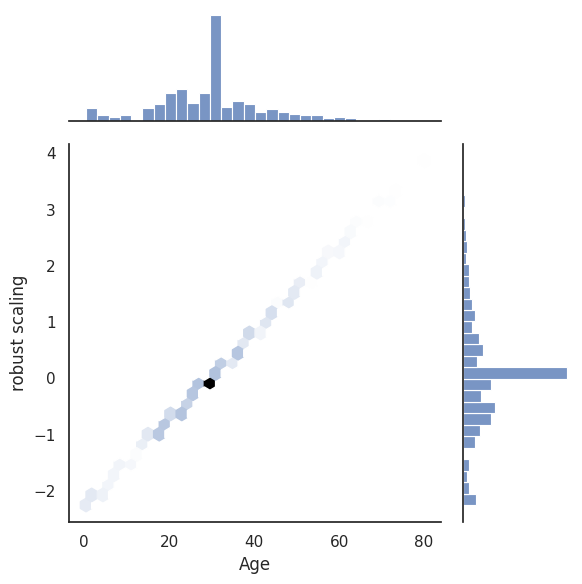

In [22]:
plot_experiment('robust scaling')

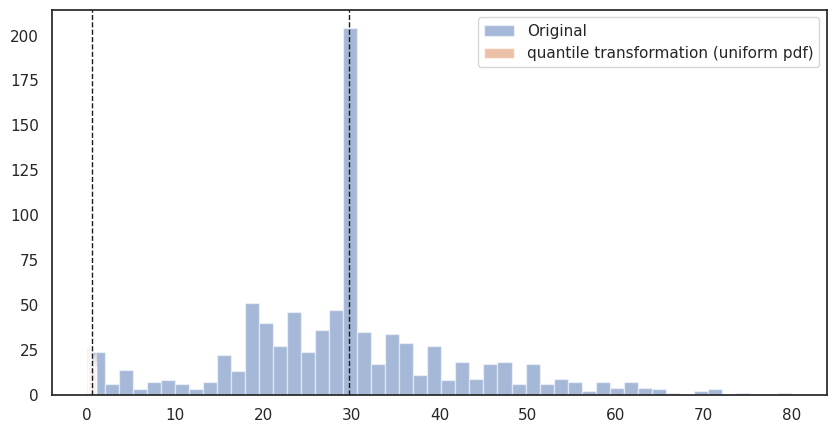

<Figure size 500x500 with 0 Axes>

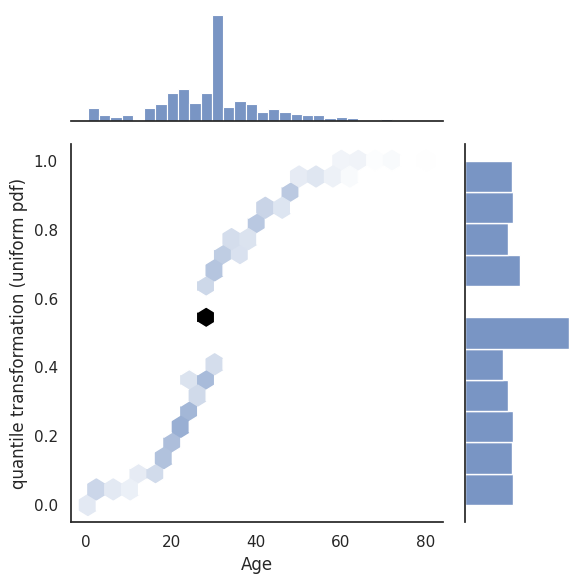

In [23]:
plot_experiment('quantile transformation (uniform pdf)')

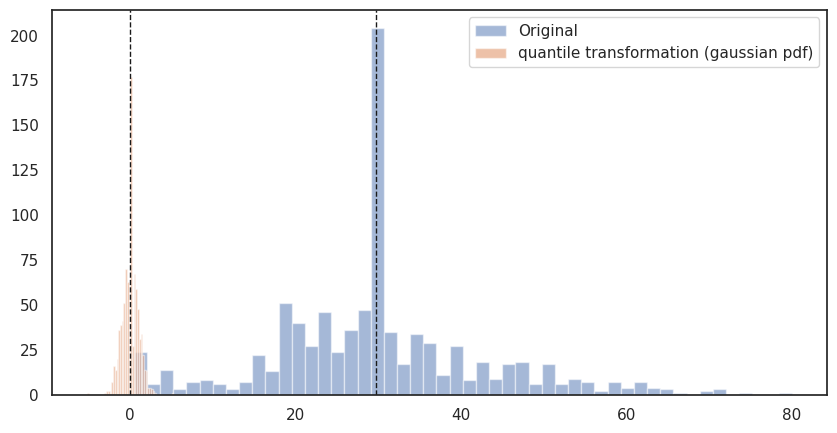

<Figure size 500x500 with 0 Axes>

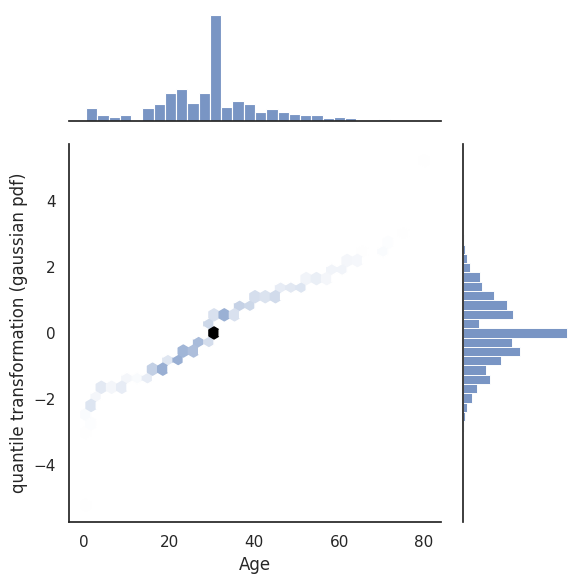

In [24]:
plot_experiment('quantile transformation (gaussian pdf)')

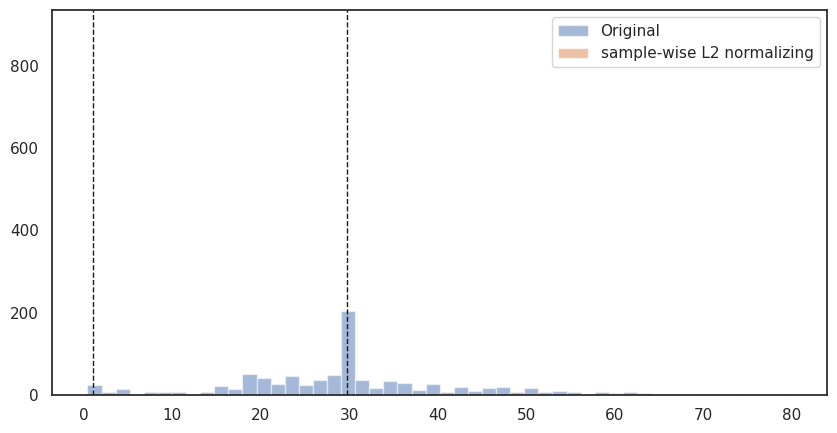

<Figure size 500x500 with 0 Axes>

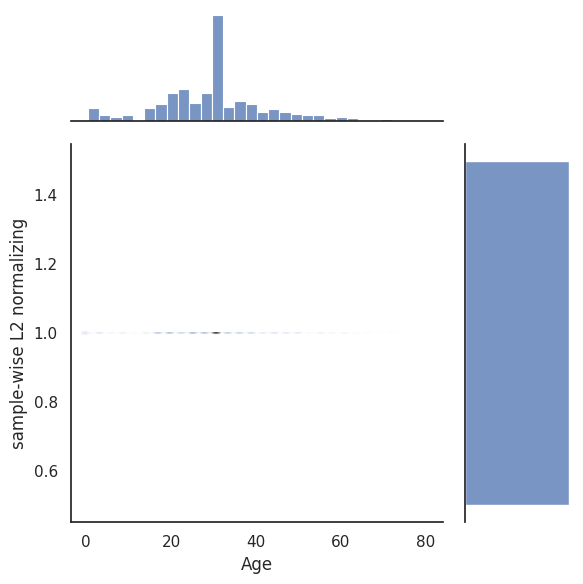

In [25]:
plot_experiment('sample-wise L2 normalizing')

In [26]:
systematic_sample(dfX[['Age', 'sample-wise L2 normalizing']], 20)

,Age,sample-wise L2 normalizing
26,29.699118,1.0
70,32.000000,1.0
114,17.000000,1.0
158,29.699118,1.0
202,34.000000,1.0
246,25.000000,1.0
290,26.000000,1.0
334,29.699118,1.0
378,20.000000,1.0
422,29.000000,1.0


# Fare

<Axes: ylabel='Frequency'>

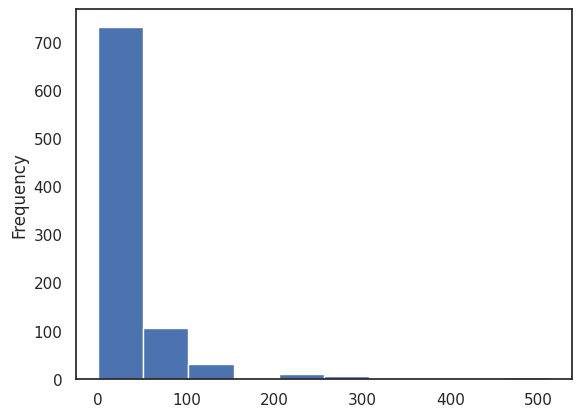

In [27]:
df["Fare"].plot(kind = "hist")

In [28]:
dfX = pd.DataFrame(df['Fare'])
col = dfX['Fare'].values.reshape(-1, 1)

scalers = [
    #('Unscaled data', X),
    ('standard scaling', StandardScaler()),
    ('min-max scaling', MinMaxScaler()),
    ('max-abs scaling', MaxAbsScaler()),
    ('robust scaling', RobustScaler(quantile_range=(25, 75))),
    ('quantile transformation (uniform pdf)', QuantileTransformer(output_distribution='uniform')),
    ('quantile transformation (gaussian pdf)', QuantileTransformer(output_distribution='normal')),
    ('sample-wise L2 normalizing', Normalizer())
]

for scaler in scalers:
    dfX[scaler[0]] = scaler[1].fit_transform(col)

In [29]:
systematic_sample(dfX, 5)

,Fare,standard scaling,min-max scaling,max-abs scaling,robust scaling,quantile transformation (uniform pdf),quantile transformation (gaussian pdf),sample-wise L2 normalizing
177,28.7125,-0.070304,0.056043,0.056043,0.617520,0.719101,0.580173,1.0
355,9.5000,-0.457142,0.018543,0.018543,-0.214564,0.363483,-0.349164,1.0
533,22.3583,-0.198244,0.043640,0.043640,0.342323,0.602809,0.260625,1.0
711,26.5500,-0.113846,0.051822,0.051822,0.523864,0.689326,0.493940,1.0
889,30.0000,-0.044381,0.058556,0.058556,0.673281,0.733708,0.624066,1.0


In [30]:
orig = dfX['Fare']
orig_mean = orig.mean()
bins = 50
alpha=0.5

def plot_experiment(name):
    normalized = dfX[name]
    plt.figure(figsize=(10,5))
    plt.hist(orig, bins, alpha=alpha, label='Original')
    plt.axvline(orig_mean, color='k', linestyle='dashed', linewidth=1)

    plt.hist(normalized, bins, alpha=alpha, label=name)
    plt.axvline(normalized.mean(), color='k', linestyle='dashed', linewidth=1)
    plt.legend(loc='upper right')

    plt.figure(figsize=(5,5))
    g = sns.jointplot(x="Fare", y=name, data=dfX, kind='hex', ratio=3)
    #sns.violinplot(x='median_income', data=dfX, )
    #sns.violinplot(x='standard scaling', data=dfX)
    #plt.boxplot(dfX['median_income'])
    #plt.boxplot(dfX['standard scaling'])
    plt.show()

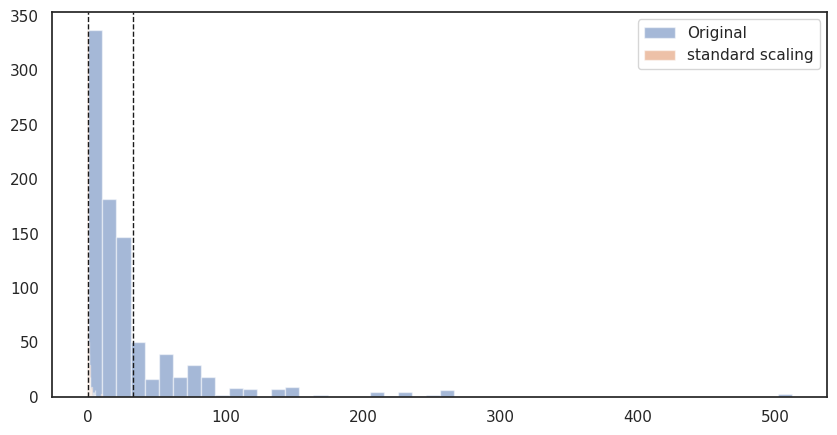

<Figure size 500x500 with 0 Axes>

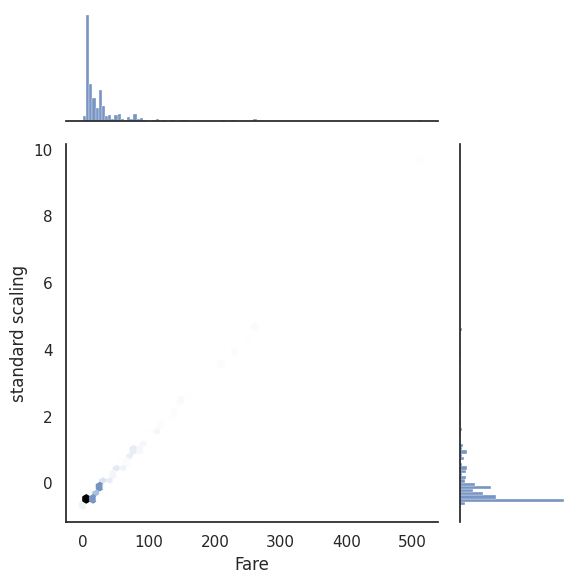

In [31]:
plot_experiment('standard scaling')

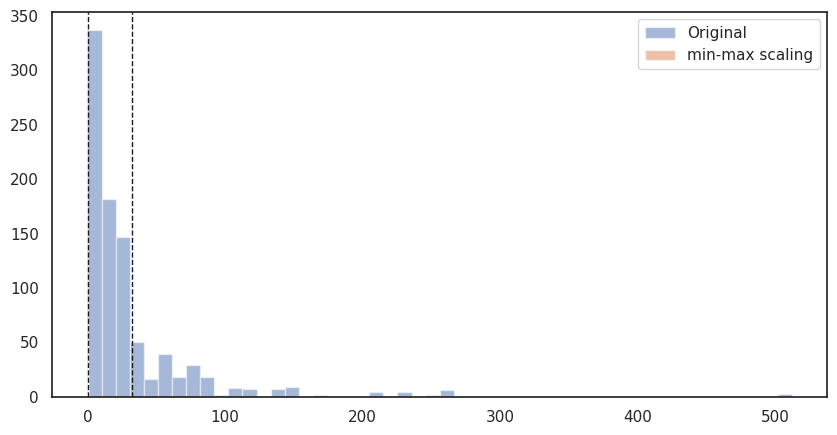

<Figure size 500x500 with 0 Axes>

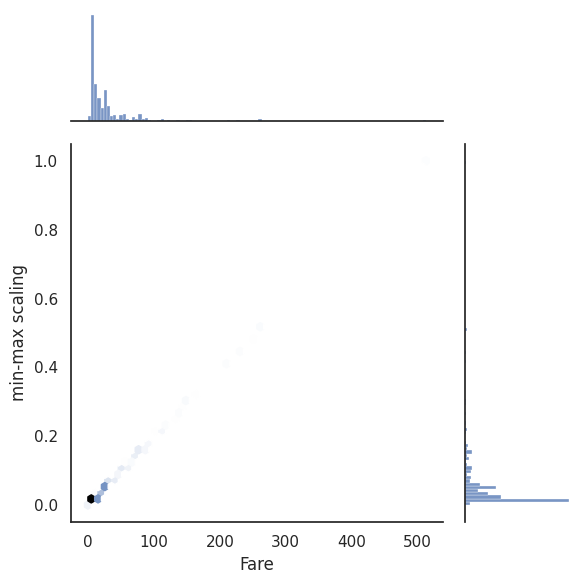

In [32]:
plot_experiment('min-max scaling')

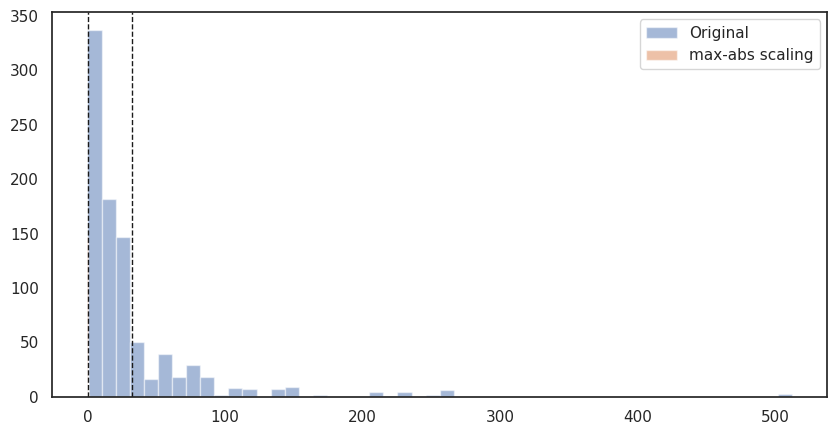

<Figure size 500x500 with 0 Axes>

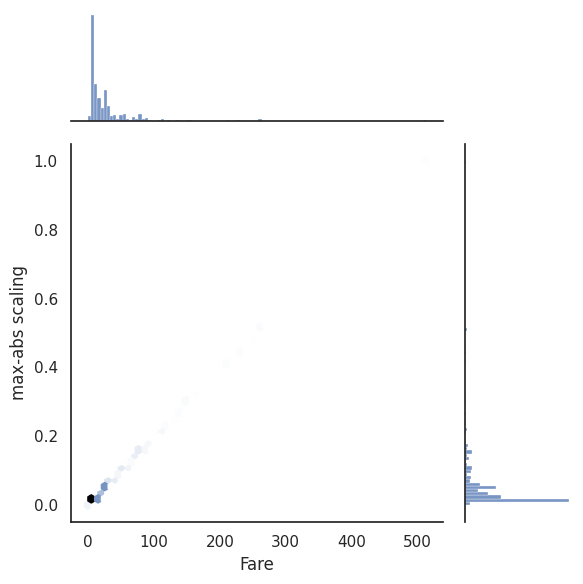

In [33]:
plot_experiment('max-abs scaling')

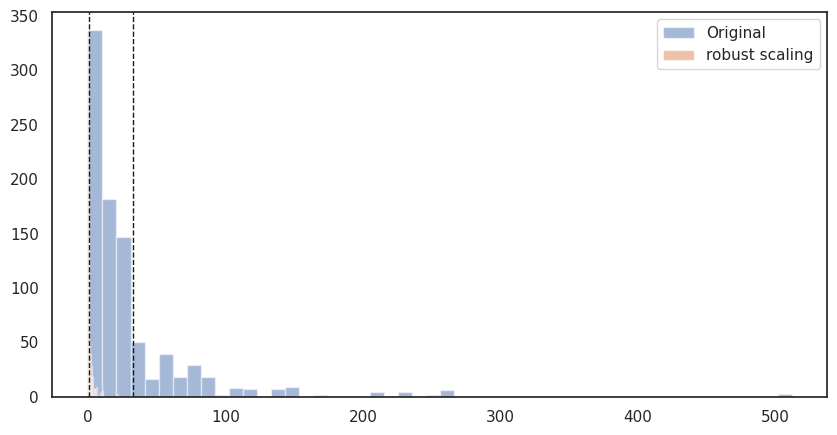

<Figure size 500x500 with 0 Axes>

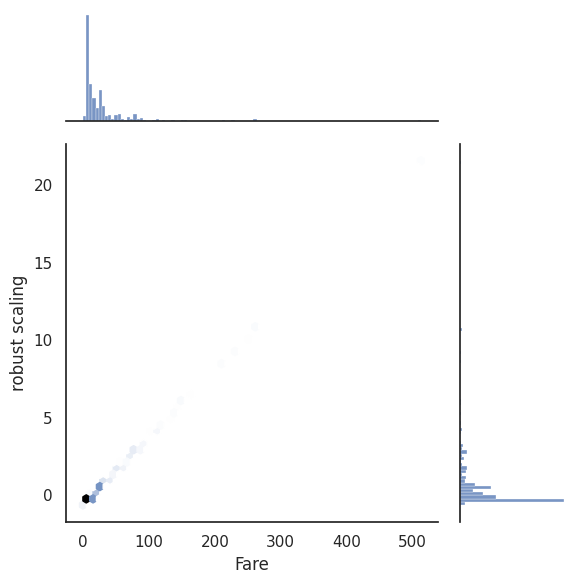

In [34]:
plot_experiment('robust scaling')

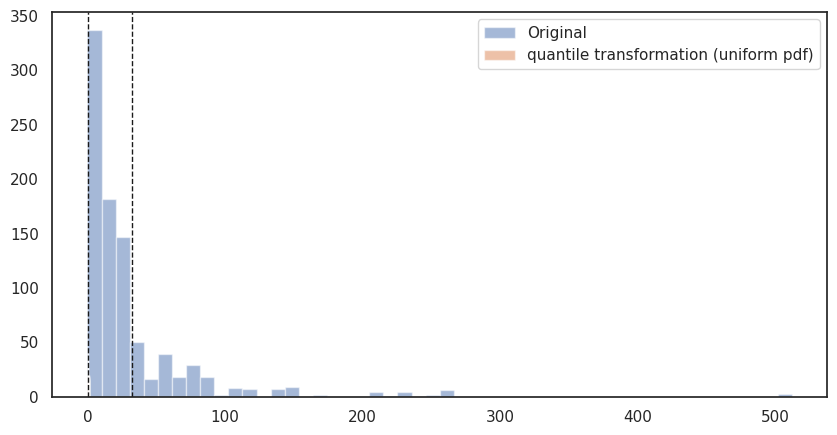

<Figure size 500x500 with 0 Axes>

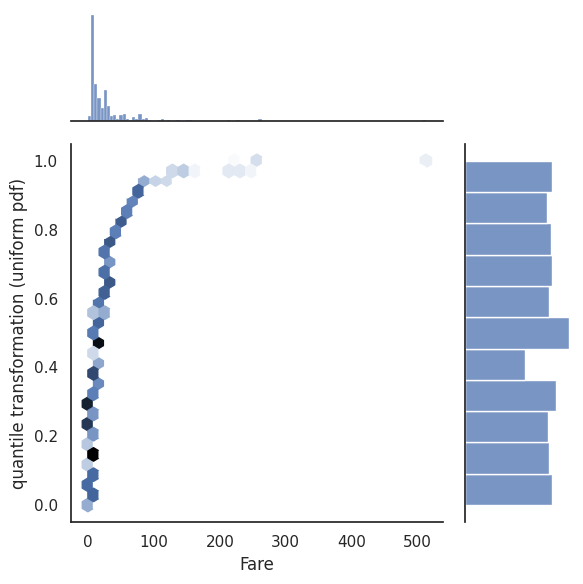

In [35]:
plot_experiment('quantile transformation (uniform pdf)')

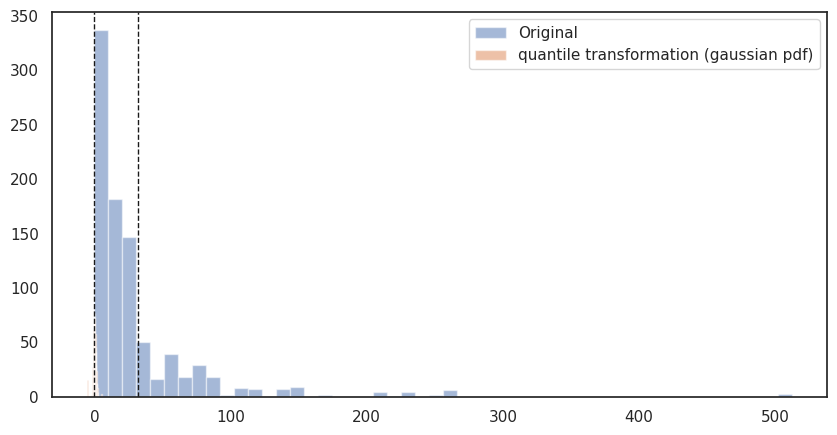

<Figure size 500x500 with 0 Axes>

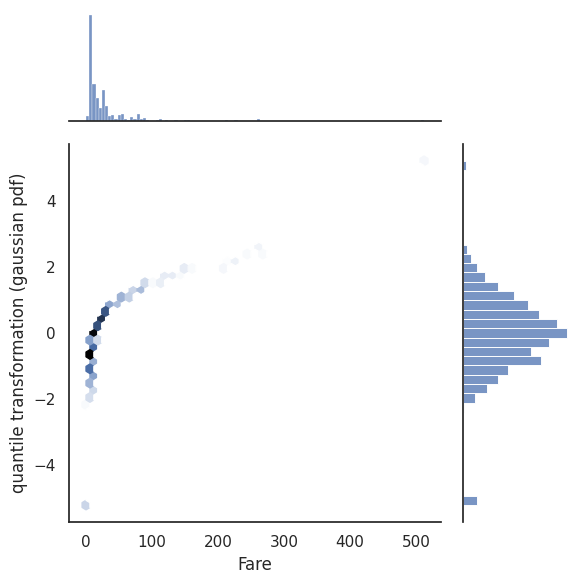

In [36]:
plot_experiment('quantile transformation (gaussian pdf)')

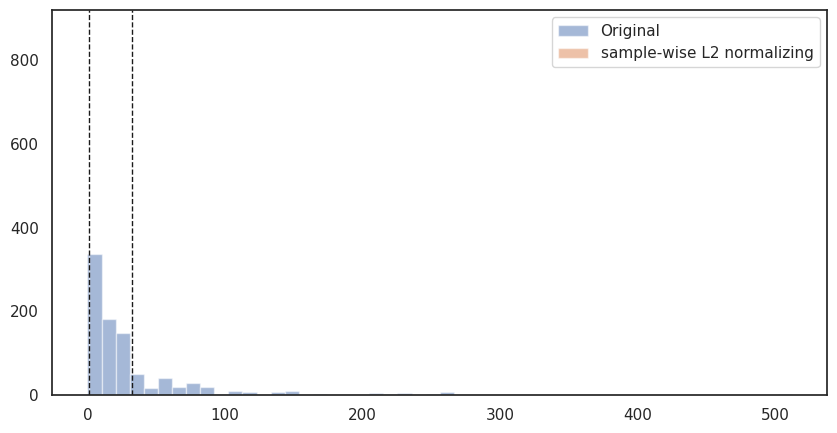

<Figure size 500x500 with 0 Axes>

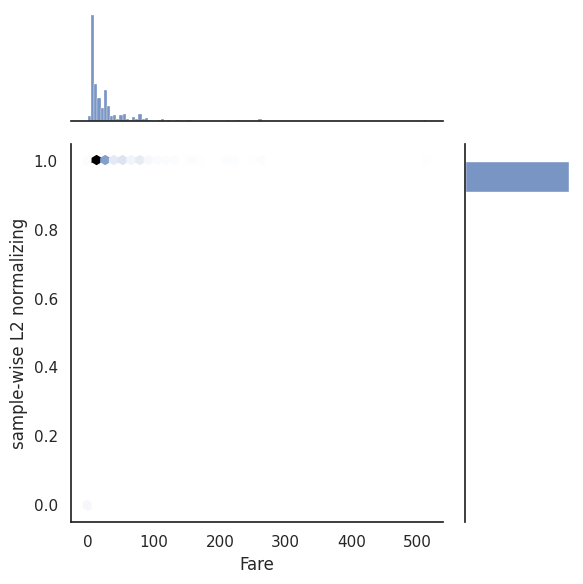

In [37]:
plot_experiment('sample-wise L2 normalizing')

In [38]:
systematic_sample(dfX[['Fare', 'sample-wise L2 normalizing']], 20)

,Fare,sample-wise L2 normalizing
27,263.0000,1.0
71,46.9000,1.0
115,7.9250,1.0
159,69.5500,1.0
203,7.2250,1.0
247,14.5000,1.0
291,91.0792,1.0
335,7.8958,1.0
379,7.7750,1.0
423,14.4000,1.0


# Sincerely, Mr. Eslam Fouad.